In [1]:
!pip install keras_facenet
import tensorflow as tf
from keras_facenet import FaceNet
import numpy as np
from tensorflow.keras import layers, models
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.cm as cm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.0 MB/s eta 0:00:00
  Created wheel for keras_facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=1952d1cb95e60bea5145d65f38ab980e3cfe861a4db18b3761a55f9cb4b81b97
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras_facenet


In [2]:
def resize_to_160(img):
    """
    img: Tensor or numpy array of shape (256, 256, 3)
    returns: Tensor (160, 160, 3)
    """
    img = tf.image.resize(img, (160, 160), method='bilinear')
    img = img.numpy()
    return img

In [3]:
def get_embedding(img):
  """
  The embedder.embeddings function expects a list of numpy arrays.
  img is already a numpy array from resize_to_160, so we wrap it in a list.
  """
  img = resize_to_160(img)
  emb = embedder.embeddings([img])[0]
  #emb = np.expand_dims(emb, axis=0)
  return emb

In [4]:
def process_row(row):
    row["embedding"] = resize_to_160(row["image"])
    return row

In [5]:
def get_embeddings(images):
  images = np.array(images['image'])
  embeddings = embedder.embeddings(images)
  #emb = np.expand_dims(emb, axis=0)
  return {"embedding": embeddings}

In [6]:
from datasets import load_dataset

ds = load_dataset("tonyassi/celebrity-1000")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [7]:
ds['train'].shape

(18184, 2)

In [8]:
embedder = FaceNet()

In [9]:
num_of_classes = 1000
keep = list(range(num_of_classes))
ds_50 = ds['train'].filter(lambda x: x["label"] in keep)


Filter:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [10]:
ds_50 = ds_50.map(process_row)

Map:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [11]:
ds_50 = ds_50.map(get_embeddings, batched=True)

Map:   0%|          | 0/18184 [00:00<?, ? examples/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 286ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


In [12]:
split_ds = ds_50.train_test_split(test_size=0.3, stratify_by_column="label",shuffle=True)
train = split_ds['train']
split_ds = split_ds['test'].train_test_split(test_size=2/3, shuffle=True)
test = split_ds['test']
val = split_ds['train']

In [13]:
print(train.shape)
print(test.shape)
print(val.shape)

(12728, 3)
(3638, 3)
(1818, 3)


In [14]:
model = models.Sequential([
    layers.Input(shape=(512,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_of_classes, activation='softmax')
])


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
x_train = np.array(train["embedding"])
y_train = np.array(train["label"])
x_val = np.array(val["embedding"])
y_val = np.array(val["label"])
x_test = np.array(test["embedding"])
y_test = np.array(test["label"])

In [17]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0932 - loss: 6.4739 - val_accuracy: 0.8685 - val_loss: 2.5073
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8426 - loss: 1.7877 - val_accuracy: 0.9532 - val_loss: 0.4567
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9454 - loss: 0.4926 - val_accuracy: 0.9659 - val_loss: 0.2306
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9539 - loss: 0.2881 - val_accuracy: 0.9670 - val_loss: 0.1692
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9618 - loss: 0.2072 - val_accuracy: 0.9670 - val_loss: 0.1360
Epoch 6/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9698 - loss: 0.1517 - val_accuracy: 0.9670 - val_loss: 0.1205
Epoch 7/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.1267 - val_accuracy: 0.9736 - val_loss: 0.1117
Epoch 8/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.1057 - val_accuracy: 0.

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │       129,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 583,994 (2.23 MB)

 Trainable params: 194,664 (760.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 389,330 (1.49 MB)

In [19]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9710 - loss: 0.0934
Accuracy: 0.9694887399673462


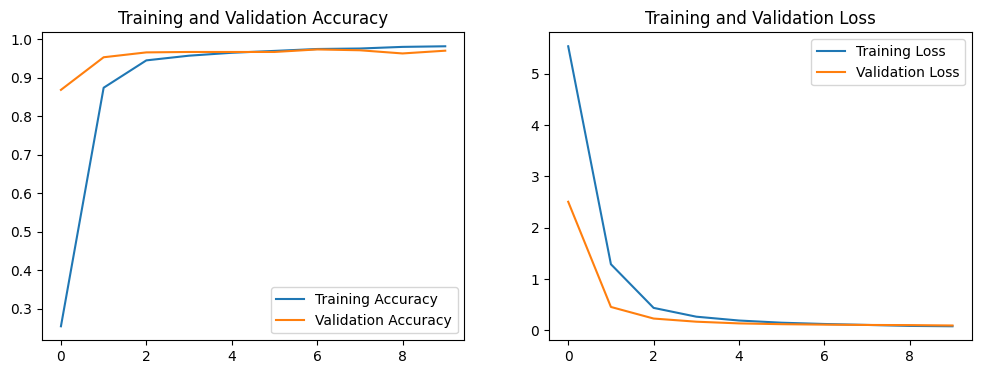

In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

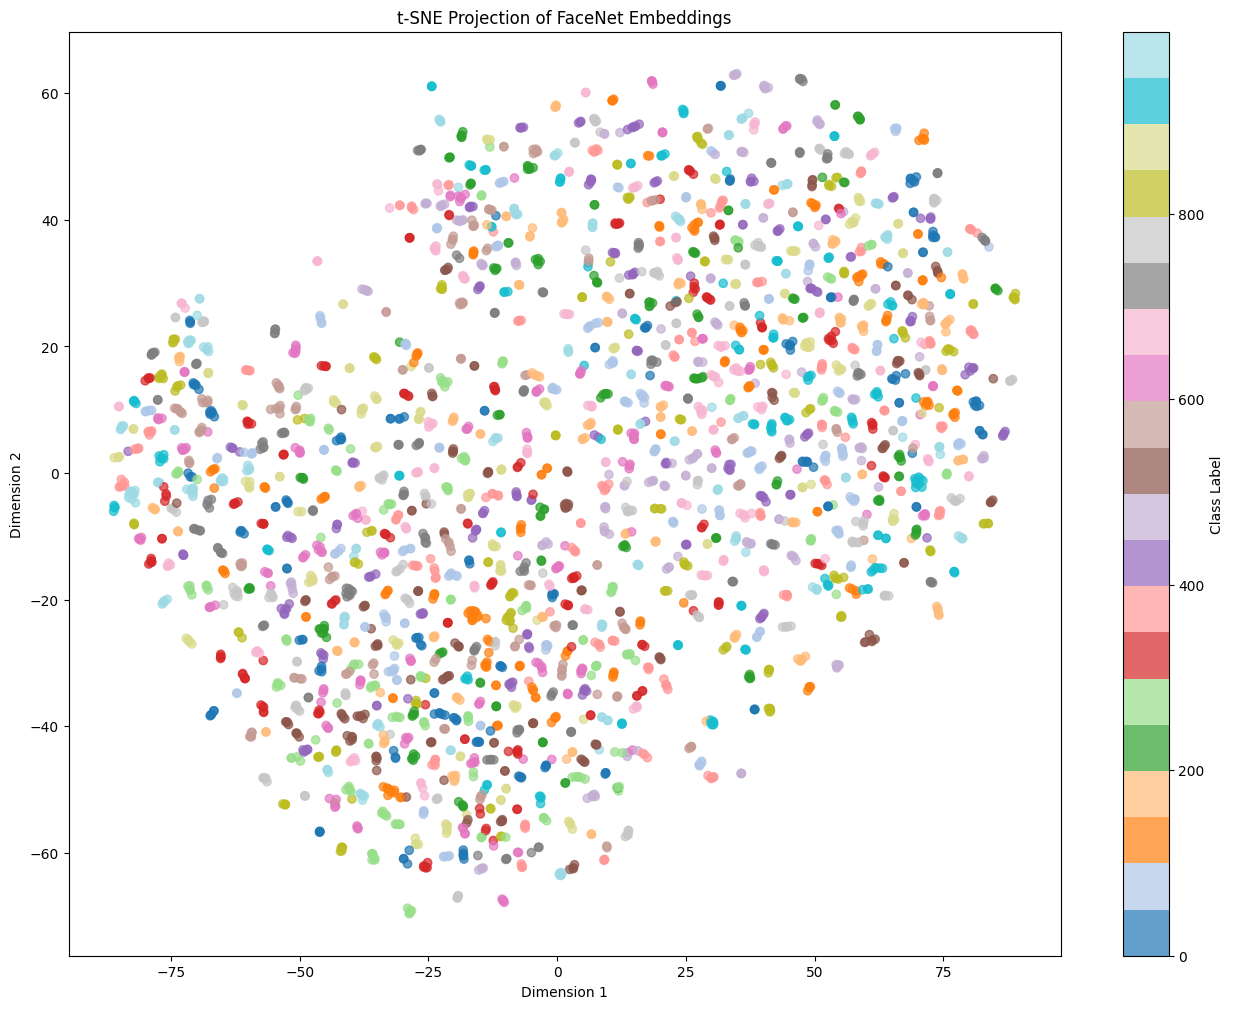

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
x_test_2d = tsne.fit_transform(x_test)

plt.figure(figsize=(16, 12))
scatter = plt.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Class Label')
plt.title('t-SNE Projection of FaceNet Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [22]:
def get_prediction(img):
  emb = get_embedding(img)
  emb = np.expand_dims(emb, axis=0)
  predictions = model.predict(emb)
  predicted_class = np.argmax(predictions)
  print(f"\nPredicted Class Index: {predicted_class}")
  print(f"Name: {ds['train'].features['label'].names[predicted_class]}")
  print(f"Confidence: {np.max(predictions) * 100:.2f}%")
  predictions = np.sort(predictions)[0,::-1]
  print(f"Top 10 Probabilities: {predictions[:10]}")
  return predicted_class

In [23]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(160, 160)):
    """
    Detects a face using MTCNN and returns a cropped RGB face.
    The input MUST be an RGB uint8 numpy array.
    """

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face


Saving Adele-2165151244.webp to Adele-2165151244.webp


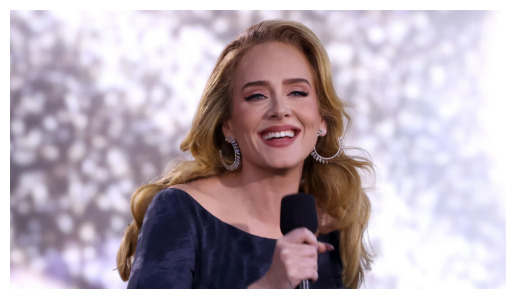

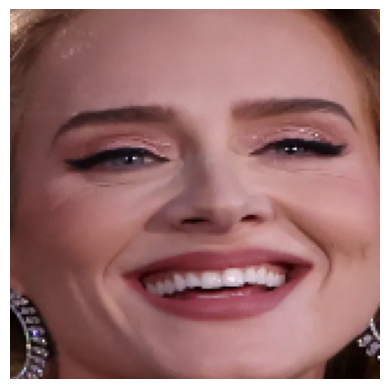

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step

Predicted Class Index: 15
Name: Adele
Confidence: 71.53%
Top 10 Probabilities: [0.71527123 0.04539242 0.0286827  0.02163193 0.01937355 0.01660015
 0.01570957 0.01301133 0.01207109 0.01075392]


In [24]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = load_img(filename)
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)

if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
    pred_class = get_prediction(cropped)

In [25]:
model.save('/content/drive/My Drive/classifier1K.h5')